# Repo Census Visualization

## Setup

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

file_path = Path("..", "..", "data", "processed", "repo-census.csv")

df = pd.read_csv(file_path)

num_cols = [
    "n_files_total", "n_files_py", "loc_total_all_text", "loc_total_py",
    "n_files_py_tests", "loc_py_tests", "n_files_py_vendor", "loc_py_vendor",
    "n_files_encoding_error", "n_files_binary"
]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

## 1. Comparison of code between old and new projects

,group,repos,total_py_files,total_py_loc,total_test_files,total_test_loc
0,new_2020s,8,2106,251033,939,88366
1,old_2000s,8,1919,332997,1181,120638


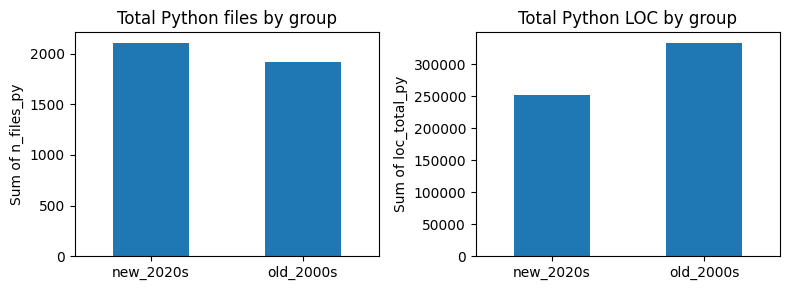

In [13]:
group_summary = (
    df.groupby("group", as_index=False)
      .agg(
          repos=("name", "count"),
          total_py_files=("n_files_py", "sum"),
          total_py_loc=("loc_total_py", "sum"),
          total_test_files=("n_files_py_tests", "sum"),
          total_test_loc=("loc_py_tests", "sum"),
      )
)

display(group_summary)

fig, axes = plt.subplots(1, 2, figsize=(8, 3))  # 1 row, 2 columns

# Chart 1
group_summary.plot(
    kind="bar",
    x="group",
    y="total_py_files",
    legend=False,
    ax=axes[0]
)
axes[0].set_title("Total Python files by group")
axes[0].set_xlabel("")
axes[0].set_ylabel("Sum of n_files_py")
axes[0].tick_params(axis="x", rotation=0)

# Chart 2
group_summary.plot(
    kind="bar",
    x="group",
    y="total_py_loc",
    legend=False,
    ax=axes[1]
)
axes[1].set_title("Total Python LOC by group")
axes[1].set_xlabel("")
axes[1].set_ylabel("Sum of loc_total_py")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()